# Three ways evals lie to you — and the statistics that catch them

Eval frameworks are good at producing a score. They are much weaker at answering the question the score exists for: **is system A actually better than system B, and by how much?** This notebook demonstrates the three failure modes that corrupt that answer, on one GPQA-Diamond-shaped dataset, using [`evalconfidence`](../README.md):

1. **Wrong winner** — an unpaired comparison buries a real improvement in noise that pairing cancels.
2. **False confidence** — repeated epochs inflate the apparent sample size, so naive intervals are too narrow.
3. **No budget plan** — without power analysis, teams can't know what gap their eval can even detect.

The dataset shape mirrors GPQA Diamond deliberately: **198 items**, binary correct/incorrect grading, **5 epochs per item at temperature ≈ 0.7**, and strongly heterogeneous item difficulty (PhD-level science questions are hard-for-both-models or easy-for-both — that shared difficulty is exactly the covariance that pairing exploits).

> **A note on the data.** This run uses a synthetic data-generating process with those GPQA statistics, so the notebook executes with zero API keys and the *true* model gap is known (4.5 points) — you can check the statistics against ground truth. A real GPQA Diamond generation run (~2,000 calls, under \$5) drops into the cell below with no other change; see the swap-in instructions.
>
> **A note on "agent" evaluation.** GPQA is QA, not tool use. The math is indifferent: an item can be a physics question or a SWE-bench task scored success/failure. Everything below applies unchanged to agent trajectories.

## The data

Each observation is one `ItemResult(item_id, model_id, score, epoch)` — the normalized unit every `evalconfidence` function consumes. Item difficulty is drawn once and **shared by both models** (a logistic item parameter $\theta_i \sim N(0, 2)$, giving the bimodal hard-for-both / easy-for-both profile); model A gets a uniform $+0.30$ logit advantage, a true gap of **4.5 accuracy points** (55.9% vs 51.5% on this seed's difficulty draw). Five epochs per item are independent Bernoulli draws given the item — the temperature-0.7 regime, where epoch repeats genuinely vary but stay correlated within item.

In [1]:
import numpy as np
from scipy.special import expit

from evalconfidence import ItemResult, compare, power, standard_error

N_ITEMS, N_EPOCHS, SEED = 198, 5, 9

rng = np.random.default_rng(SEED)
theta = rng.normal(0.0, 2.0, N_ITEMS)        # shared item difficulty (bimodal)
p_b = expit(theta)                           # model B: 51.5% true accuracy
p_a = expit(theta + 0.30)                    # model A: 55.9% (true gap 4.5 pts)

results_a, results_b = [], []
for i in range(N_ITEMS):
    for k in range(N_EPOCHS):
        results_a.append(ItemResult(item_id=f"q{i:03d}", model_id="model-a",
                                    score=float(rng.random() < p_a[i]), epoch=k))
        results_b.append(ItemResult(item_id=f"q{i:03d}", model_id="model-b",
                                    score=float(rng.random() < p_b[i]), epoch=k))

print(f"True accuracies: A={p_a.mean():.3f}, B={p_b.mean():.3f} "
      f"(true gap {100 * (p_a.mean() - p_b.mean()):.1f} pts)")
print(f"{len(results_a)} observations per model ({N_ITEMS} items x {N_EPOCHS} epochs)")

True accuracies: A=0.559, B=0.515 (true gap 4.5 pts)
990 observations per model (198 items x 5 epochs)


**To run this notebook on real data instead**, replace the cell above with the output of any eval framework — every cell downstream is unchanged:

```python
from evalconfidence import from_inspect          # Inspect AI .eval logs
results_a = from_inspect("logs/..._gpqa_diamond_model-a.eval")
results_b = from_inspect("logs/..._gpqa_diamond_model-b.eval")

from evalconfidence import from_dataframe        # or anything tabular
results_a = from_dataframe(df_a, item_id="qid", model_id="system", score="acc")
```

`evalconfidence` never makes API calls — generation happens upstream (e.g. `inspect eval inspect_evals/gpqa_diamond --model <m> --epochs 5 --temperature 0.7`), and the analysis here re-runs on the saved logs forever for free.

## Figure 1 — Wrong winner: the comparison most teams run vs. the one they should

The standard move is to score each model, put a confidence interval on each, and eyeball the overlap. That is an **unpaired** comparison: its variance is $\mathrm{Var}(A) + \mathrm{Var}(B)$, dominated by *which questions are hard* — variation that has nothing to do with which model is better, and that both models share.

A **paired** comparison differences the two models *within each item* before averaging. Shared item difficulty cancels: $\mathrm{Var}(A-B) = \mathrm{Var}(A) + \mathrm{Var}(B) - 2\,\mathrm{Cov}(A,B)$, and on a benchmark like GPQA the covariance term is large. `compare()` pairs automatically whenever the two systems share items.

In [2]:
paired = compare(results_a, results_b)                  # pairs on shared item_ids
unpaired = compare(results_a, results_b, paired=False)  # the eyeball test, formalized

print("--- Unpaired (what most teams do) ---")
print(unpaired)
print()
print("--- Paired (same data) ---")
print(paired)

--- Unpaired (what most teams do) ---
model-a is estimated to outperform model-b by 4.3 points, 95% CI [-2.8, 11.5] (A−B). The difference is NOT significant at alpha=0.05 (p=0.2316, welch_t).
Note: Epoch repeats were aggregated to per-item mean scores.

--- Paired (same data) ---
model-a is estimated to outperform model-b by 4.3 points, 95% CI [1.0, 7.7] (A−B). The difference is significant at alpha=0.05 (p=0.0122, paired_t).
Pairing reduced the comparison variance by 4.5x: the 198 paired items deliver the precision of ~882 unpaired items.
Note: Epoch repeats were aggregated to per-item mean scores.


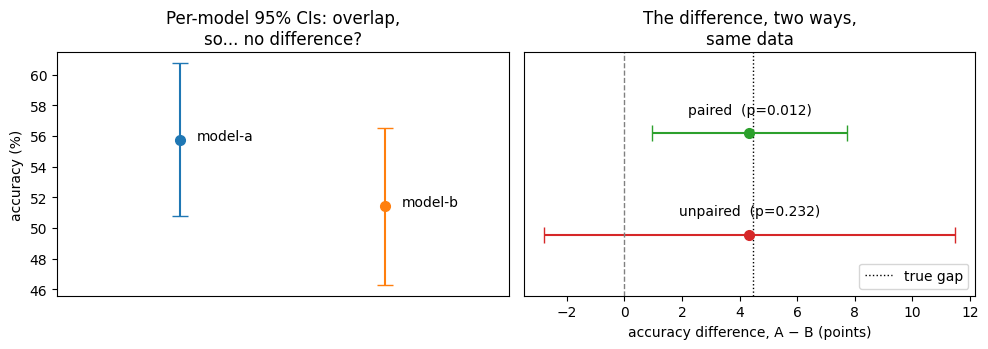

In [3]:
import matplotlib.pyplot as plt

se_a, se_b = standard_error(results_a), standard_error(results_b)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

# Left: the per-model intervals people eyeball.
for x, (label, se) in enumerate([("model-a", se_a), ("model-b", se_b)]):
    lo, hi = se.ci
    ax1.errorbar([x], [100 * se.mean], yerr=[[100 * se.mean - 100 * lo], [100 * hi - 100 * se.mean]],
                 fmt="o", capsize=6, markersize=7)
    ax1.annotate(label, (x, 100 * se.mean), xytext=(12, 0), textcoords="offset points")
ax1.set_xlim(-0.6, 1.6); ax1.set_xticks([])
ax1.set_ylabel("accuracy (%)")
ax1.set_title("Per-model 95% CIs: overlap,\nso... no difference?")

# Right: the difference itself, unpaired vs paired, on the same data.
for y, (label, res) in enumerate([("unpaired", unpaired), ("paired", paired)]):
    lo, hi = res.ci_diff
    color = "tab:red" if not res.significant else "tab:green"
    ax2.errorbar([100 * res.diff], [y], xerr=[[100 * res.diff - 100 * lo], [100 * hi - 100 * res.diff]],
                 fmt="o", capsize=6, markersize=7, color=color)
    ax2.annotate(f"{label}  (p={res.p_value:.3f})", (100 * res.diff, y),
                 xytext=(0, 14), textcoords="offset points", ha="center")
ax2.axvline(0, color="gray", lw=1, ls="--")
ax2.axvline(100 * (p_a.mean() - p_b.mean()), color="black", lw=1, ls=":", label="true gap")
ax2.set_ylim(-0.6, 1.8); ax2.set_yticks([])
ax2.set_xlabel("accuracy difference, A − B (points)")
ax2.set_title("The difference, two ways,\nsame data")
ax2.legend(loc="lower right")
fig.tight_layout()

**Takeaway.** Both views come from the *same 1,980 scored responses*. The unpaired comparison spans zero (95% CI [−2.8, +11.5], p = 0.23) — by the usual eyeball test, "no significant difference," and the real 4.5-point improvement gets shelved. Pairing differences the models within each question first, cancels the shared item difficulty, and the same data give a clear verdict: CI [+1.0, +7.7], p = 0.012, the interval comfortably containing the true gap. The variance-reduction factor was **4.5×** — these 198 paired items deliver the precision of roughly **880 unpaired** items. Pairing is free precision: it only requires running both systems on the same questions, which most teams already do and then throw away at analysis time.

## Figure 2 — False confidence: 990 observations that aren't 990

Running 5 epochs per item is good practice — it averages out sampling randomness. But the 990 resulting observations are **not independent**: scores of the same item repeat the item's difficulty 5 times. A naive standard error divides by $\sqrt{990}$ as if they were, and comes out too small. `standard_error()` reports the naive and cluster-robust numbers side by side, so the gap is visible rather than silent.

In [4]:
se_a = standard_error(results_a)   # clusters by item automatically (epochs detected)
print(se_a)

# The temperature-0 extreme: 5 *identical* epochs add zero information,
# and the design effect comes out = K = 5 exactly (naive SE sqrt(5) too small).
rng0 = np.random.default_rng(SEED + 100)
results_t0 = []
for i in range(N_ITEMS):
    s = float(rng0.random() < p_a[i])
    results_t0.extend(ItemResult(item_id=f"q{i:03d}", model_id="model-a", score=s, epoch=k)
                      for k in range(N_EPOCHS))
se_t0 = standard_error(results_t0)
print(f"\nTemperature-0 extreme: inflation {se_t0.inflation:.2f}x, "
      f"design effect {se_t0.design_effect:.2f} (theory: exactly {N_EPOCHS})")

Mean score: 0.5576  (n=990 observations)
  Naive i.i.d. SE:    0.0158  ->  95% CI [0.5266, 0.5886]
  Cluster-robust SE:  0.0253  ->  95% CI [0.5076, 0.6075]  (198 clusters by item)
  Inflation: 1.60x  (design effect 2.57)
  The naive interval treats all 990 observations as independent; the cluster-robust interval accounts for dependence within the 198 clusters and is the honest one to report.

Temperature-0 extreme: inflation 2.24x, design effect 5.02 (theory: exactly 5)


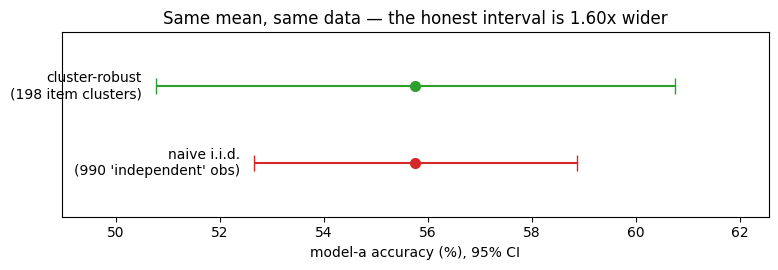

In [5]:
fig, ax = plt.subplots(figsize=(8, 2.8))
rows = [
    ("naive i.i.d.\n(990 'independent' obs)", se_a.se_naive, se_a.ci_naive, "tab:red"),
    ("cluster-robust\n(198 item clusters)", se_a.se_clustered, se_a.ci_clustered, "tab:green"),
]
for y, (label, se, (lo, hi), color) in enumerate(rows):
    ax.errorbar([100 * se_a.mean], [y], xerr=[[100 * (se_a.mean - lo)], [100 * (hi - se_a.mean)]],
                fmt="o", capsize=6, markersize=7, color=color)
    ax.annotate(label, (100 * lo, y), xytext=(-10, 0), textcoords="offset points",
                ha="right", va="center")
ax.set_ylim(-0.7, 1.7); ax.set_yticks([])
ax.set_xlabel("model-a accuracy (%), 95% CI")
ax.set_title(f"Same mean, same data — the honest interval is {se_a.inflation:.2f}x wider")
ax.margins(x=0.18)
fig.tight_layout()

**Takeaway.** The mean is identical; only the honesty of the interval changes. At temperature 0.7, epoch repeats genuinely vary, but within-item correlation still inflates the true standard error by **1.60×** (design effect 2.6) over the naive number — a team quoting the narrow interval will call ~1.6×-too-small differences "significant" and ship false wins at a real α far above the nominal 5%. The extreme case makes the mechanism unmistakable: at temperature 0, the 5 epochs are identical, the extra 792 rows carry *zero* information, and the design effect comes out at **5.0 = K exactly**, as theory predicts. Epochs are not free sample size; they only buy precision on the within-item noise.

## Figure 3 — Budget planning: what can this eval even see?

The two failures above are diagnosed after the money is spent. `power()` works *before*: given the variance from a pilot (or a baseline guess), it answers how many items are needed to detect a target gap (`mde` → `n`), or the smallest gap detectable at a given size (`n` → `mde`), or the achieved power when both are fixed.

In [6]:
# Variance from this notebook's own data, used as the pilot:
plan_unpaired = power(results_a, n=N_ITEMS)               # one-system pilot -> two-arm plan
plan_paired = power((results_a, results_b), n=N_ITEMS)    # paired pilot -> paired plan
print(plan_unpaired)
print()
print(plan_paired)
print()
print(power((results_a, results_b), mde=paired.diff, n=N_ITEMS))  # how lucky was Fig 1?

With 198 unpaired items, the minimum detectable gap at alpha=0.05 and 80% power is 10.0 points.
Per-item comparison variance: 0.2538.
Note: Epoch repeats were aggregated to per-item mean scores.
Note: Variance estimated from a single-system pilot of 198 items; planning a two-arm unpaired comparison (n = items per arm, variance doubled for the second arm). A paired design would need fewer.

With 198 paired items, the minimum detectable gap at alpha=0.05 and 80% power is 4.8 points.
Per-item comparison variance: 0.05841.
Note: Epoch repeats were aggregated to per-item mean scores.
Note: Variance estimated from a paired pilot of 198 shared items.

With 198 paired items, a true gap of 4.3 points is detected with 72% power at alpha=0.05 (target was 80%).
Per-item comparison variance: 0.05841.
Note: Epoch repeats were aggregated to per-item mean scores.
Note: Variance estimated from a paired pilot of 198 shared items.


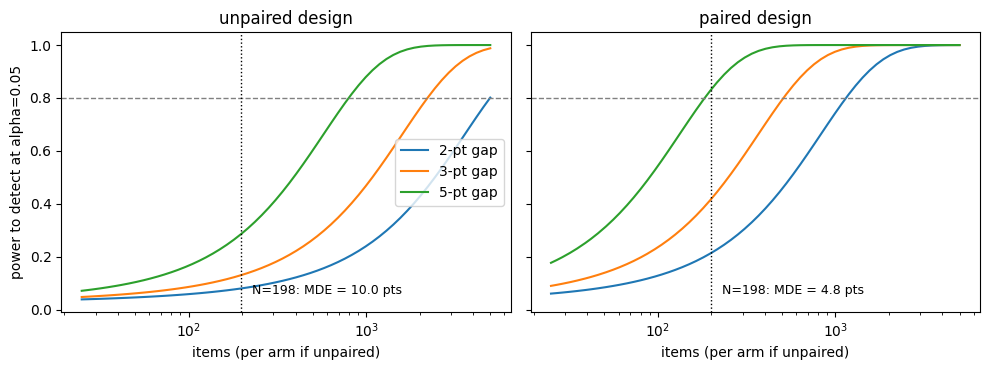

In [7]:
gaps = [0.02, 0.03, 0.05]
ns = np.unique(np.geomspace(25, 5000, 60).astype(int))
designs = [("unpaired design", plan_unpaired.variance),
           ("paired design", plan_paired.variance)]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (name, var) in zip(axes, designs):
    for gap in gaps:
        curve = [power(baseline_var=var, mde=gap, n=int(n)).power_achieved for n in ns]
        ax.plot(ns, curve, label=f"{100 * gap:.0f}-pt gap")
    ax.axhline(0.8, color="gray", lw=1, ls="--")
    ax.axvline(N_ITEMS, color="black", lw=1, ls=":")
    mde_198 = power(baseline_var=var, n=N_ITEMS).mde_detectable
    ax.annotate(f"N=198: MDE = {100 * mde_198:.1f} pts", (N_ITEMS, 0.06),
                xytext=(8, 0), textcoords="offset points", fontsize=9)
    ax.set_xscale("log")
    ax.set_xlabel("items (per arm if unpaired)")
    ax.set_title(name)
axes[0].set_ylabel("power to detect at alpha=0.05")
axes[0].legend(loc="center right")
fig.tight_layout()

**Takeaway.** Most people are surprised by the left panel: at GPQA Diamond's size, an **unpaired** comparison can only detect a **10-point** accuracy gap at 80% power — a 5-point improvement needs ~800 items per arm, and a 3-point one over 2,200. Nobody's 198-item leaderboard delta of "+3 points" means much unpaired. Pairing (right panel) drops the minimum detectable gap at N=198 to **4.8 points**, and detecting 3 points becomes feasible at ~510 items. It also scores this notebook's own Figure 1: the observed 4.3-point paired win had just **72% power** — we got a slightly lucky draw, and `power()` is the tool that says so *before* the run, not after.

## Closing the loop

One dataset, three corrections, and the four questions a decision needs answered:

| Question | Answer here | Function |
|---|---|---|
| Which system is better? | A, by 4.3 pts, 95% CI [+1.0, +7.7] | `compare()` |
| How confident should I be? | p = 0.012 *paired*; unpaired the same data say p = 0.23 | `compare()` |
| How much confidence is dependence-inflated? | naive SE is 1.60× too small (5.0× design effect at temp 0) | `standard_error()` |
| How many items do I actually need? | 10-pt MDE unpaired @198; ~510 paired items for a 3-pt gap | `power()` |

All of it runs on results you already have — `from_inspect()` for Inspect AI logs, `from_dataframe()` for anything tabular — with no model calls and no framework lock-in.